In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any

from src.build_network import ResIN, BNA
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
# OUTPATH = "../../output/results-summary-091324/"
OUTPATH = "../../output/results-summary-042425/"
print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


In [2]:
anes_all = pd.read_csv(ROOTPATH + "data/anes_out_090624.csv").drop(columns=["Unnamed: 0"])
YEARS = [2000, 2004, 2008, 2012, 2016, 2020]
anes_all = anes_all[anes_all["year"].isin(YEARS)]
anes_all["ft_rep_net"] = anes_all["ft_rep"] - anes_all["ft_dem"] # compute the net value of ft rep/dem
anes_all.head()


,year,gov_health,guar_jobs,us_isolate,aid_black,abort,spend_serv,def_spend,aff_act_1,aff_act_2,...,hw_blacks,hw_his,hw_asian,it_access,it_campaign,left_right,lbrl_cnsv,dem_rep,weights,ft_rep_net
11295,2000,5.0,6.0,NaN,NaN,2.0,3.0,6.0,5.0,5.0,...,4.0,4.0,4.0,1.0,1.0,NaN,NaN,5.0,1.2886,16.0
11296,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,4.0,7.0,1.0,1.0,5.0,NaN,NaN,3.0,0.8959,NaN
11297,2000,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,...,1.0,6.0,5.0,1.0,5.0,NaN,NaN,1.0,1.0454,-30.0
11298,2000,NaN,NaN,2.0,NaN,4.0,NaN,NaN,5.0,5.0,...,5.0,4.0,1.0,5.0,5.0,NaN,5.0,3.0,0.6005,-5.0
11299,2000,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5.0,5.0,...,4.0,5.0,1.0,5.0,5.0,NaN,6.0,7.0,1.9270,70.0


In [3]:
NODE_COLS = ["spend_serv",  "abort", "gov_health", "guar_jobs", "aid_black"]

COV_COLS = ["ft_rep_net"]

In [4]:
RESIN_DICT = {}
BNA_DICT = {}
NEUTRAL_VAL_DICT = {}
for year in YEARS:
    print("processing:", year)
    anes_year = anes_all[anes_all["year"]==year].copy()
    anes_year = anes_year[NODE_COLS + COV_COLS]
    resin = ResIN(df=anes_year, node_cols=NODE_COLS)
    resin.make_graph(square_corr=False, remove_nan=True)
    resin.compute_covariates(covariate_cols=COV_COLS)
    resin.adjust_coordinates()
    resin.get_item_size()
    resin.set_edge_distance()
    RESIN_DICT[year] = resin
    NEUTRAL_VAL_DICT[year] = np.nanmean(anes_year["ft_rep_net"])

    bna = BNA(df=anes_year, node_cols=NODE_COLS)
    bna.make_graph()
    bna.compute_covariates(covariate_col="ft_rep_net")
    BNA_DICT[year] = bna 

processing: 2000
processing: 2004
processing: 2008
processing: 2012
processing: 2016
processing: 2020


## Visualizations

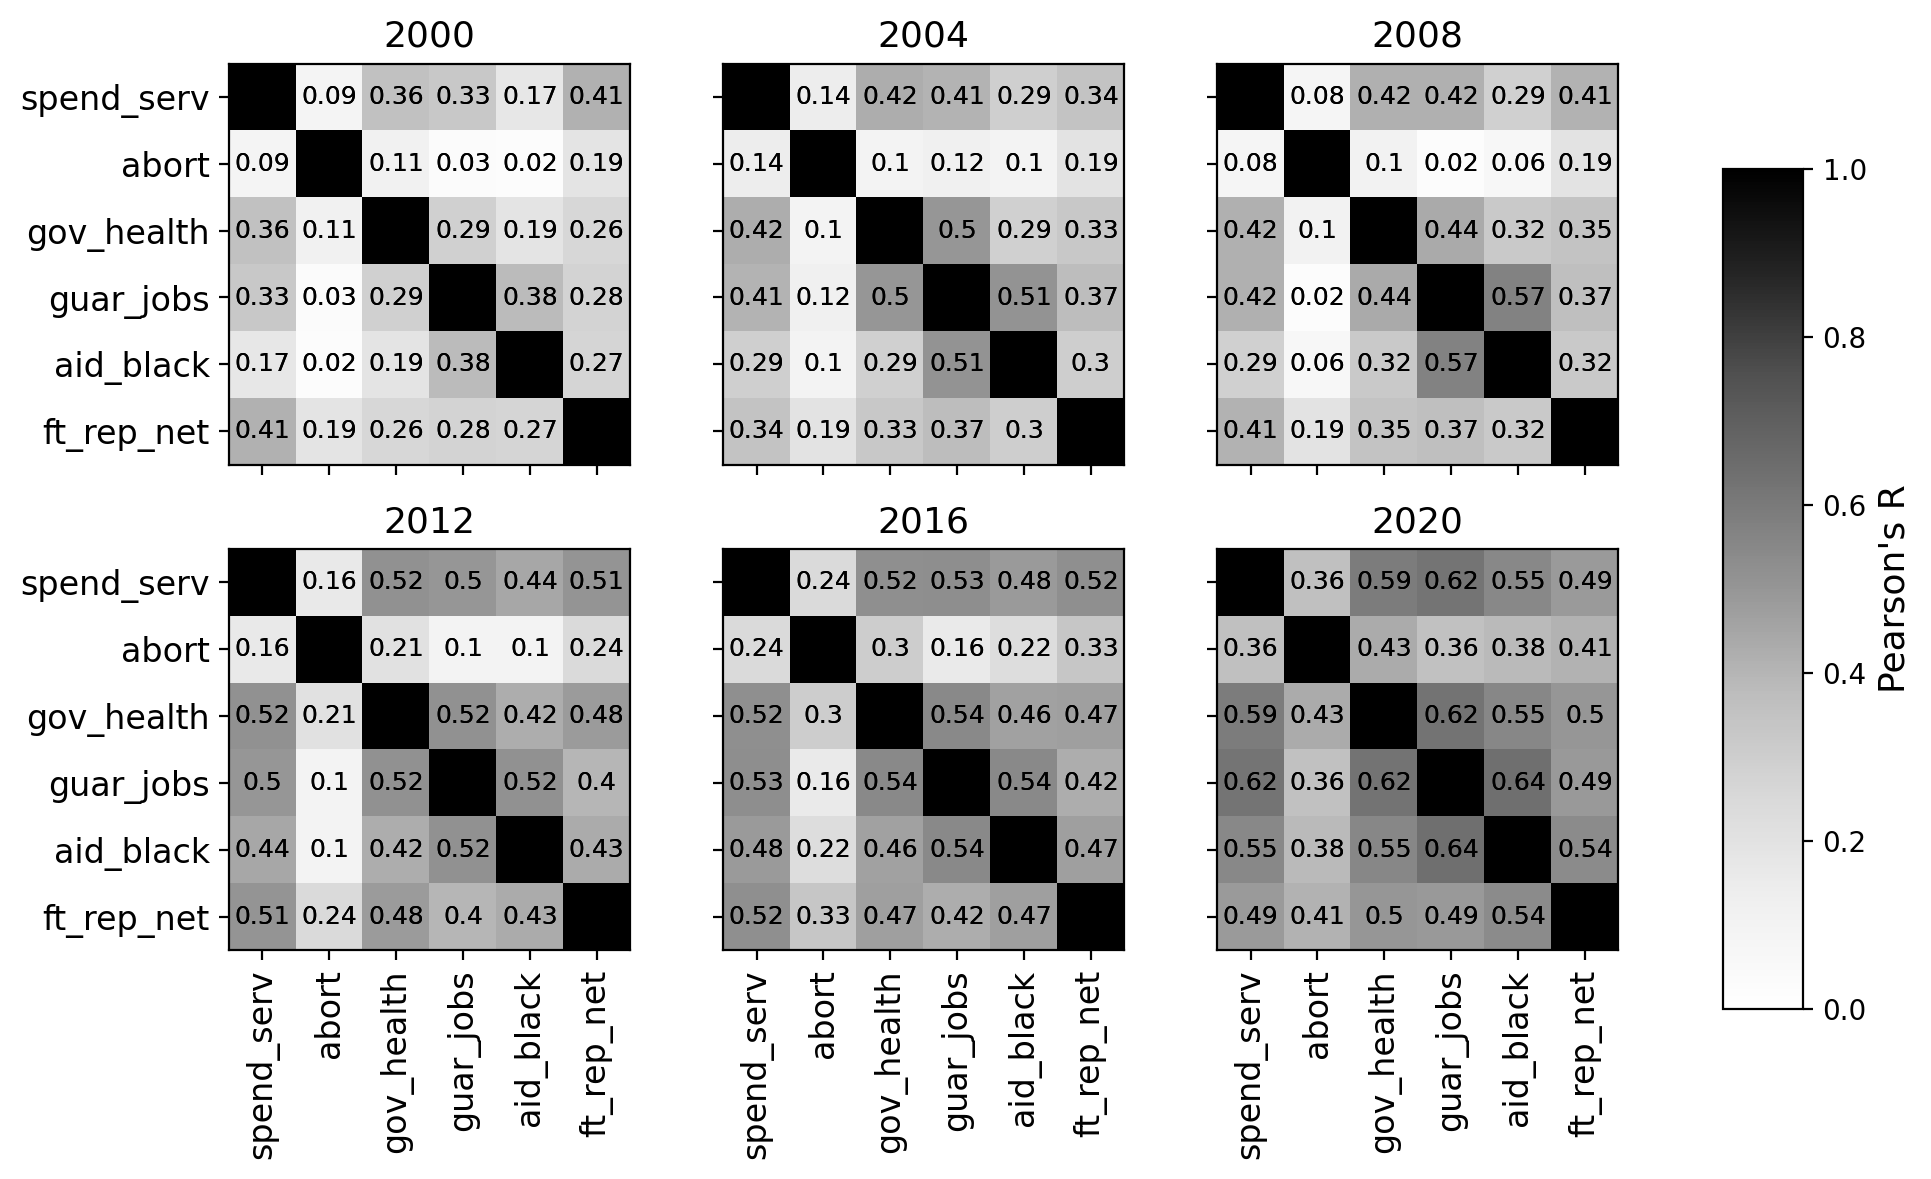

In [5]:
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(10,6), sharex=True, sharey=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    subdf = anes_all[anes_all["year"]==year][NODE_COLS + COV_COLS]
    mat = abs(subdf.corr(method="pearson").values)
    ims = ax[i].imshow(mat, cmap="Greys")
    ax[i].set_title(year, fontsize=13)
    ims.set_clim(0, 1)
    for (y,x),label in np.ndenumerate(mat):
        ax[i].text(x,y,round(label,2),ha="center",va="center", fontsize=9)
        ax[i].text(x,y,round(label,2),ha="center",va="center", fontsize=9)
    ax[i].set_xticks(range(6), NODE_COLS + COV_COLS, rotation=90, fontsize=12)
    ax[i].set_yticks(range(6), NODE_COLS + COV_COLS, fontsize=12)
plt.tight_layout()
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
cbar = fig.colorbar(ims, cax=cbar_ax)
cbar.set_label(label="Pearson's R", size=13)
# plt.savefig(OUTPATH + "issue-corr.pdf", dpi=300, bbox_inches="tight")

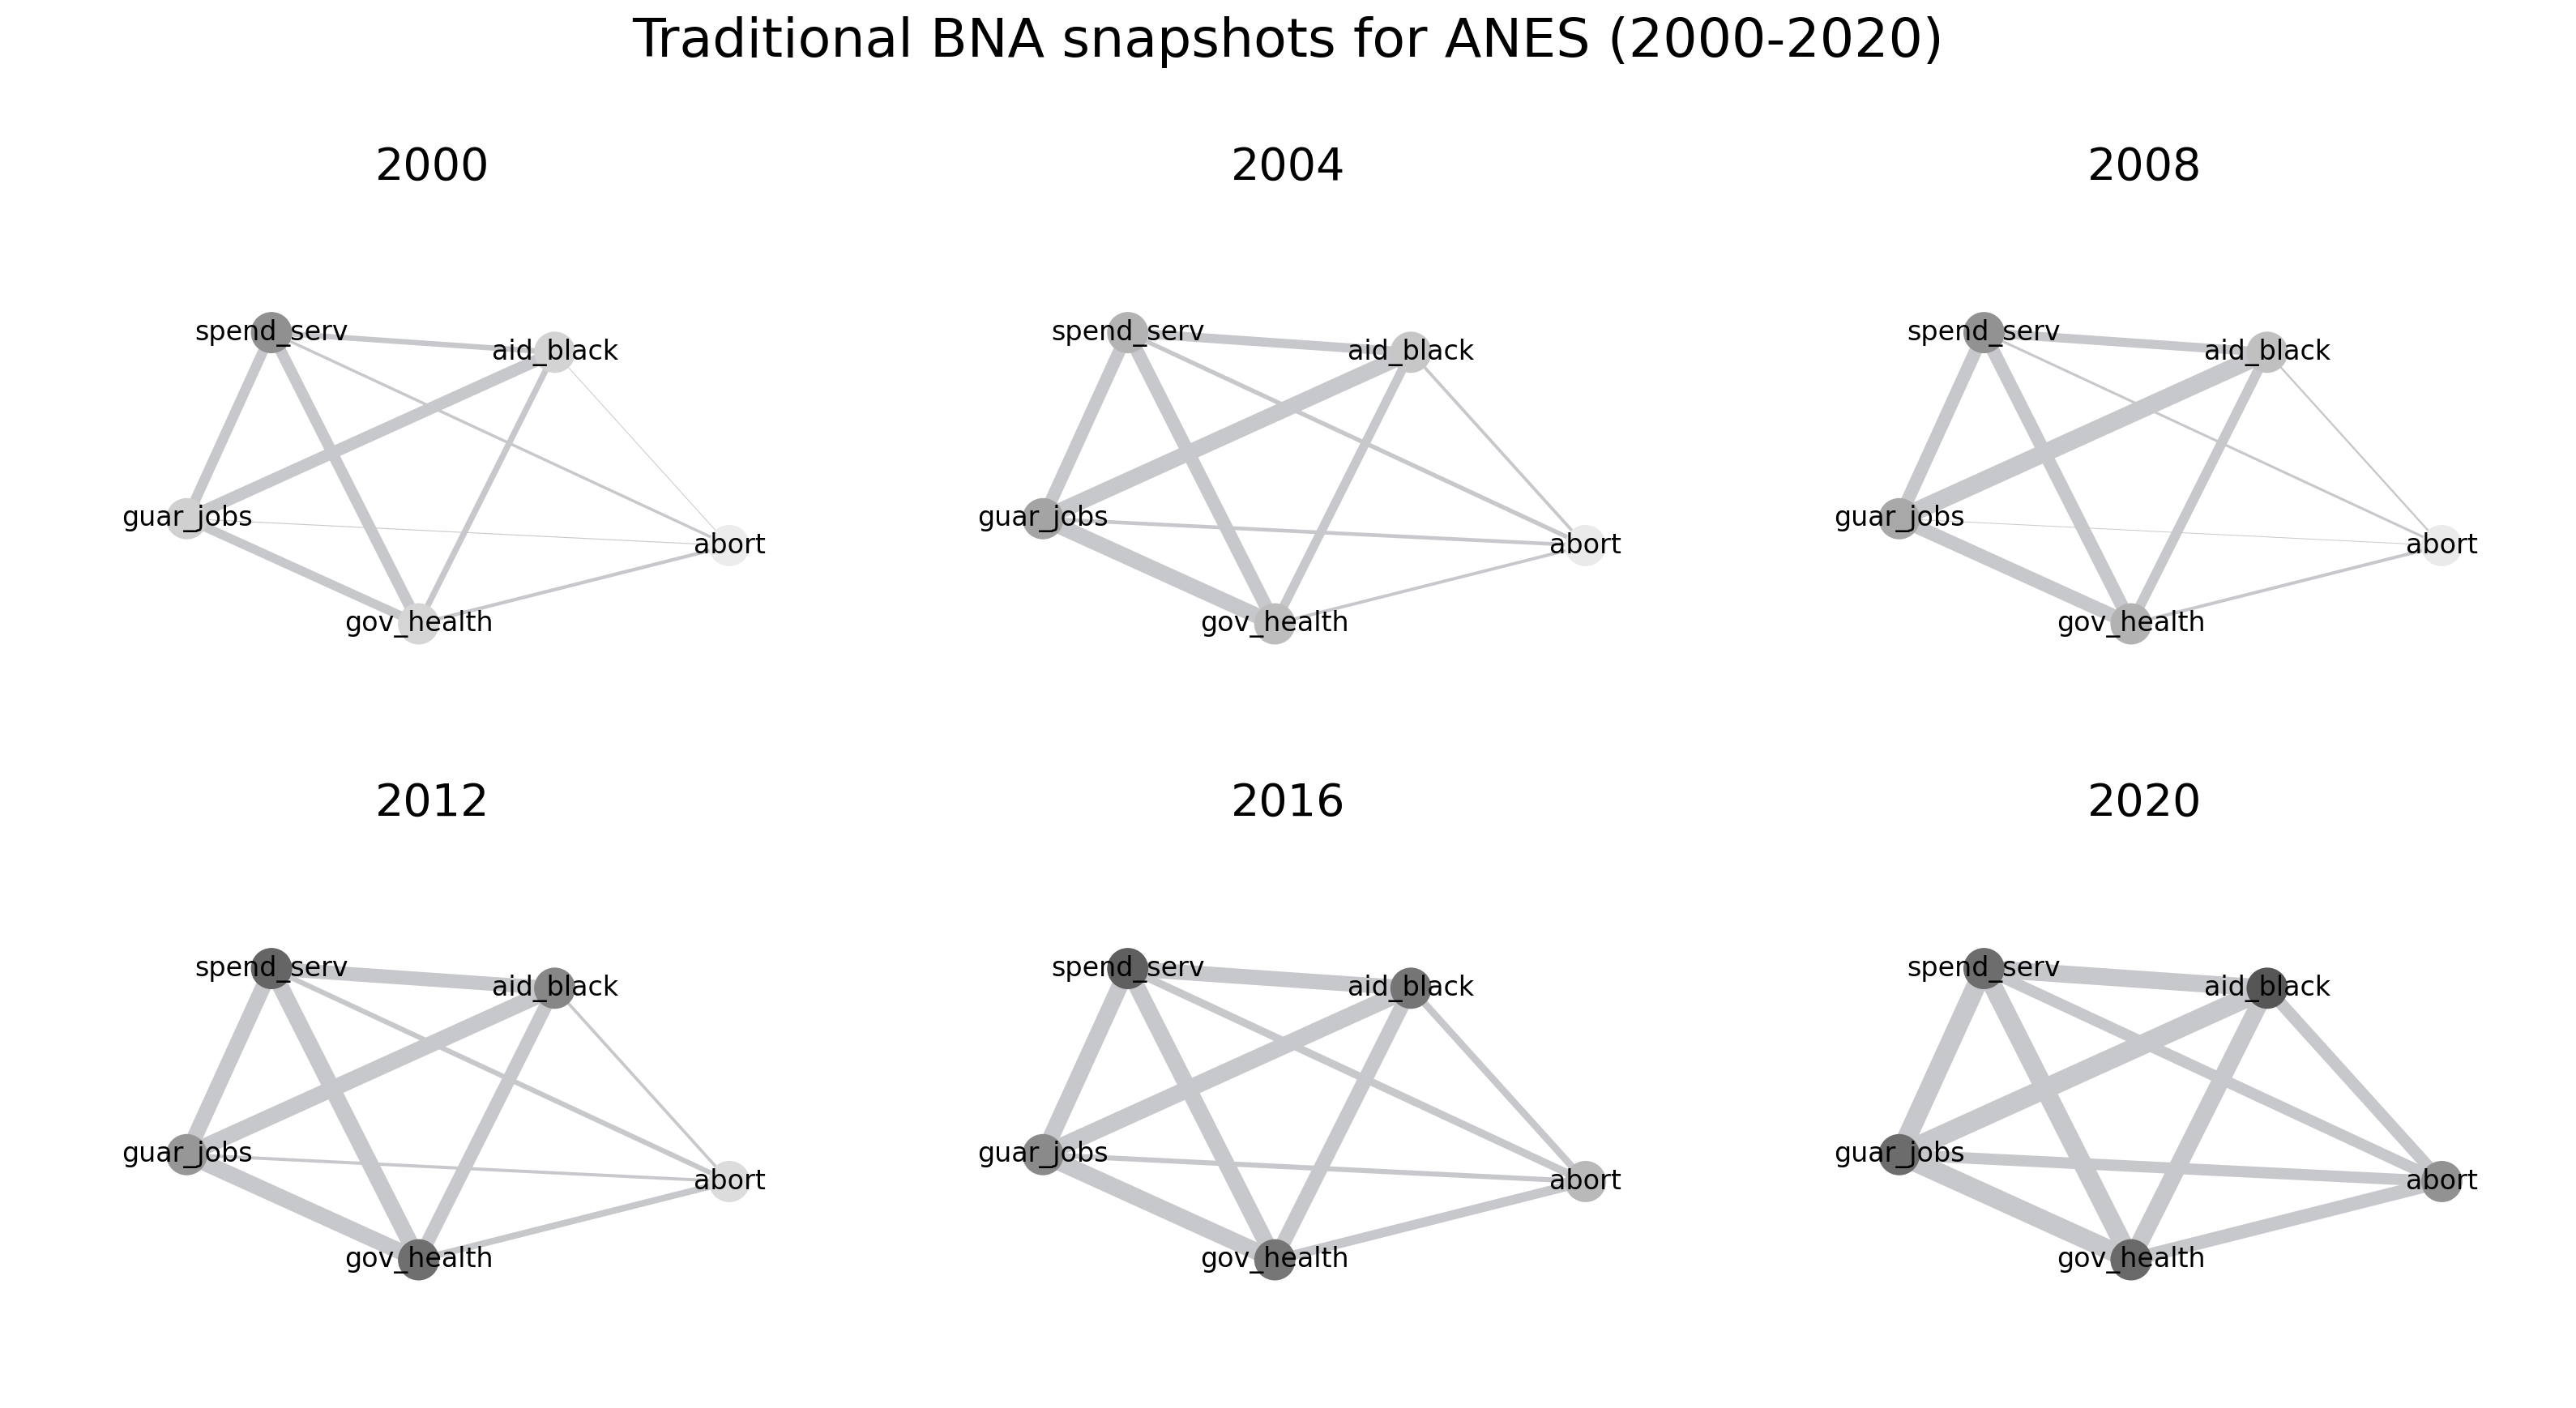

In [7]:
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(16,8))
ax = [x for ls in ax for x in ls]
pos = nx.spring_layout(BNA_DICT[2020].g, iterations=200, seed=42)
for i, (year, bna) in enumerate(BNA_DICT.items()):
    colors = [abs(bna.g.nodes[n]["corr_ft_rep_net"]) for n in bna.g.nodes()]
    # pos = nx.spring_layout(bna.g, iterations=200, seed=42)
    nodes_plot = nx.draw_networkx_nodes(
        bna.g, ax=ax[i],
        pos = pos, 
        # node_color="#C7C8CC",
        node_color=colors, 
        # alpha=1,
        cmap="Greys",
        vmin=0.1, vmax=.7,
    )
    weights = np.array([bna.g[u][v]["weight"] for u,v in bna.g.edges()])*14
    edges_plot = nx.draw_networkx_edges(
        bna.g, ax=ax[i], edge_color="#C7C8CC", pos=pos, width=weights,
    )
    nx.draw_networkx_labels(bna.g, ax=ax[i], pos=pos)
    ax[i].set_title(year, fontsize=20)
    ax[i].set_ylim(-1.4, 1.4)
    ax[i].set_xlim(-1.4, 1.4)
    ax[i].axis("off")
plt.tight_layout()
plt.suptitle(f"Traditional BNA snapshots for ANES (2000-2020)", fontsize=24, y=1.08)
# plt.savefig(OUTPATH + f"anes_bna_snapshot_2000_2020.pdf", dpi=300, bbox_inches="tight")
plt.savefig(OUTPATH + f"anes_bna_snapshot_2000_2020.png", dpi=300, bbox_inches="tight")

In [7]:
YEARS_TO_FLIP = [2020]
for y in YEARS_TO_FLIP:
    RESIN_DICT[y].left_right_flip()

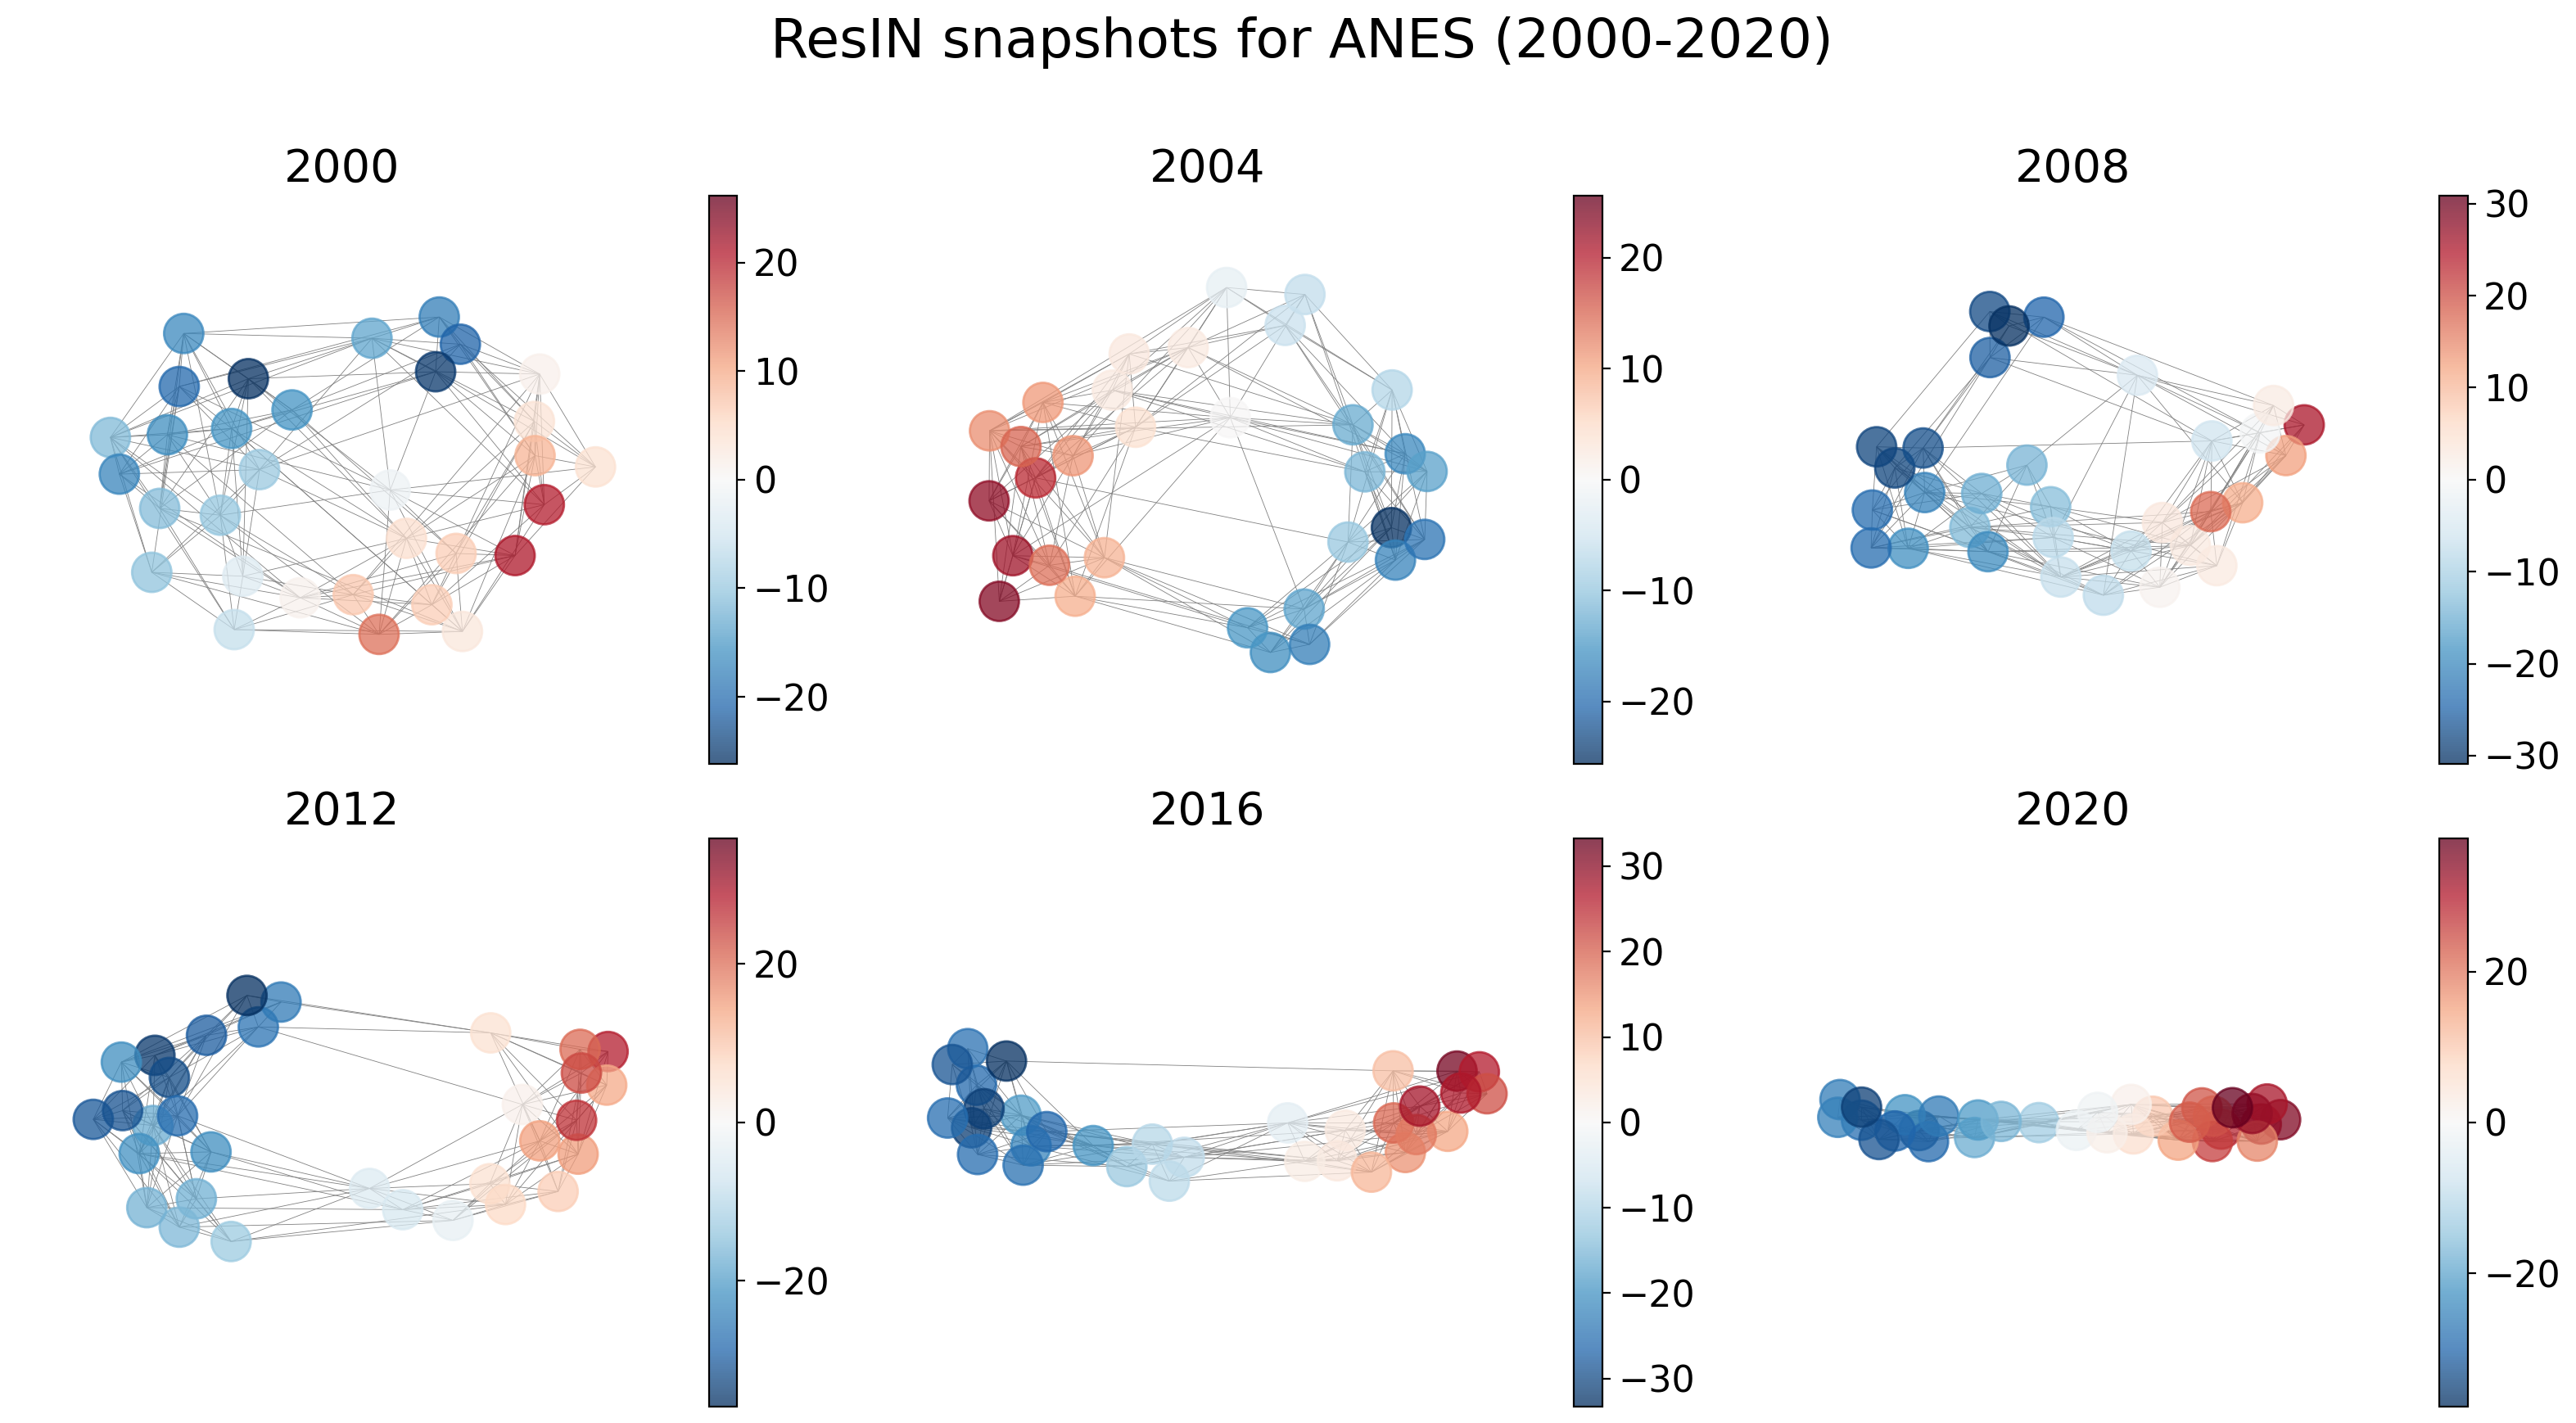

In [8]:
from sklearn.preprocessing import MinMaxScaler

color_var = "ft_rep_net"
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(16,8))
ax = [x for ls in ax for x in ls]

for i, (year,resin) in enumerate(RESIN_DICT.items()):
    NEUTRAL_VAL = 0
    # colors = [distinguish_operational_symbolic(x) for x in list(resin.g.nodes())]
    colors = [resin.node_attrs[color_var][x] for x in resin.g.nodes()]
    color_bound = max([NEUTRAL_VAL-min(colors), max(colors)-NEUTRAL_VAL])
    sizes = np.array([resin.node_attrs["size"][x] for x in resin.g.nodes()]).reshape(-1,1)
    scaler = MinMaxScaler().fit(sizes)
    sizes = scaler.transform(sizes).reshape(-1)
    sizes = sizes*2000**1/2

    nodes_plot = nx.draw_networkx_nodes(
        resin.g, ax=ax[i], 
        pos=resin.pos_new, 
        # node_size=sizes,
        node_color=colors, 
        # node_color="lightgrey",
        cmap="RdBu_r", 
        alpha=.75, label=False,
        vmin=NEUTRAL_VAL-color_bound, vmax=NEUTRAL_VAL+color_bound,  # if not normalizing colorbar
        ) 
    edges_plot = nx.draw_networkx_edges(
        resin.g, ax=ax[i], edge_color="grey", pos=resin.pos_new, width=.3,
    )
    # nx.draw_networkx_labels(resin.g, ax=ax[i], pos=resin.pos_new)
    ax[i].set_title(year, fontsize=20)
    clb = plt.colorbar(nodes_plot)
    clb.ax.tick_params(labelsize=16)
    ax[i].set_ylim(-1.4, 1.4)
    ax[i].set_xlim(-1.4, 1.4)
    ax[i].axis("off")
plt.tight_layout()
plt.suptitle(f"ResIN snapshots for ANES (2000-2020)", fontsize=24, y=1.08)
plt.savefig(OUTPATH + f"anes_resin_snapshot_2000_2020_FTNET_COLOR.pdf", dpi=300, bbox_inches="tight")